In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [17]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [18]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1
242,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1


In [19]:
df.columns = df.columns.str.capitalize()
df.columns

Index(['Day', 'Month', 'Year', 'Temperature', 'Rh', 'Ws', 'Rain', 'Ffmc',
       'Dmc', 'Dc', 'Isi', 'Bui', 'Fwi', 'Classes', 'Region'],
      dtype='str')

In [22]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),"not fire", "fire")

In [23]:
df.groupby("Month")["Classes"].value_counts(normalize=True)*100

Month  Classes 
6      not fire    58.333333
       fire        41.666667
7      fire        62.295082
       not fire    37.704918
8      fire        82.258065
       not fire    17.741935
9      not fire    61.666667
       fire        38.333333
Name: proportion, dtype: float64

In [ ]:
##drop month,day and yyear
df.drop(['Day','Year'],axis=1,inplace=True)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[["Month"]])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Month']),
    index=df.index
)
encoded_df
df = pd.concat([encoded_df, df], axis=1)
df

,Month_7,Month_8,Month_9,Day,Month,Year,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Fwi,Classes,Region
0,0.0,0.0,0.0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,0.0,0.0,0.0,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,0.0,0.0,0.0,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,0.0,0.0,0.0,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,0.0,0.0,0.0,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,0.0,0.0,1.0,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire,1
239,0.0,0.0,1.0,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,1
240,0.0,0.0,1.0,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
241,0.0,0.0,1.0,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [38]:
df.drop("Month", axis = 1, inplace=True)

In [39]:
df.head()

,Month_7,Month_8,Month_9,Day,Year,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Fwi,Classes,Region
0,0.0,0.0,0.0,1,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,0.0,0.0,0.0,2,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,0.0,0.0,0.0,3,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,0.0,0.0,0.0,4,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,0.0,0.0,0.0,5,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [40]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [41]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [42]:
df.tail()

,Month_7,Month_8,Month_9,Day,Year,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Fwi,Classes,Region
238,0.0,0.0,1.0,26,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,0.0,0.0,1.0,27,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,0.0,0.0,1.0,28,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,0.0,0.0,1.0,29,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,0.0,0.0,1.0,30,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [43]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [45]:
df.rename(columns={"Fwi": "FWI"}, inplace=True)

In [52]:
df.drop(["Year", "Day"], axis=1, inplace=True)

In [53]:
## Independent And dependent features
X=df.drop('FWI',axis=1)
y=df['FWI']

In [54]:
X.head()

,Month_7,Month_8,Month_9,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Classes,Region
0,0.0,0.0,0.0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,0.0,0.0,0.0,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,0.0,0.0,0.0,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,0.0,0.0,0.0,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,0.0,0.0,0.0,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [55]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [56]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [57]:
X_train.shape,X_test.shape

((182, 14), (61, 14))

In [58]:
## Feature Selection based on correlaltion
X_train.corr()

,Month_7,Month_8,Month_9,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Classes,Region
Month_7,1.000000,-0.342314,-0.309353,0.073622,0.056312,0.094258,-0.128283,0.155797,0.057971,0.012717,0.024103,0.045904,0.113701,-0.084436
Month_8,-0.342314,1.000000,-0.342314,0.570223,-0.361496,-0.036671,-0.082031,0.356019,0.485788,0.508690,0.420345,0.503976,0.309925,0.031383
Month_9,-0.309353,-0.342314,1.000000,-0.437290,0.207487,-0.038345,0.107734,-0.307098,-0.313287,-0.254955,-0.236411,-0.303553,-0.250257,-0.006823
Temperature,0.073622,0.570223,-0.437290,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
Rh,0.056312,-0.361496,0.207487,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,0.094258,-0.036671,-0.038345,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.128283,-0.082031,0.107734,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
Ffmc,0.155797,0.356019,-0.307098,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
Dmc,0.057971,0.485788,-0.313287,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
Dc,0.012717,0.508690,-0.254955,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838


<Axes: >

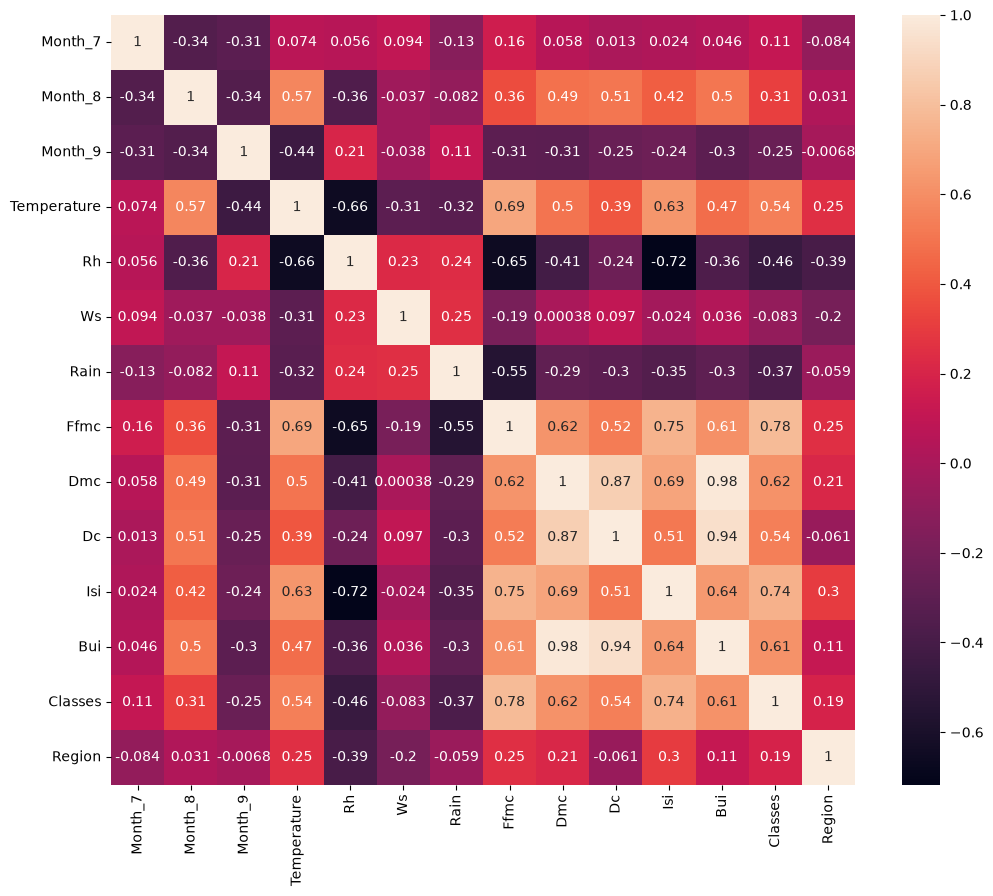

In [59]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


In [60]:
X_train.corr()

,Month_7,Month_8,Month_9,Temperature,Rh,Ws,Rain,Ffmc,Dmc,Dc,Isi,Bui,Classes,Region
Month_7,1.000000,-0.342314,-0.309353,0.073622,0.056312,0.094258,-0.128283,0.155797,0.057971,0.012717,0.024103,0.045904,0.113701,-0.084436
Month_8,-0.342314,1.000000,-0.342314,0.570223,-0.361496,-0.036671,-0.082031,0.356019,0.485788,0.508690,0.420345,0.503976,0.309925,0.031383
Month_9,-0.309353,-0.342314,1.000000,-0.437290,0.207487,-0.038345,0.107734,-0.307098,-0.313287,-0.254955,-0.236411,-0.303553,-0.250257,-0.006823
Temperature,0.073622,0.570223,-0.437290,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
Rh,0.056312,-0.361496,0.207487,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,0.094258,-0.036671,-0.038345,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.128283,-0.082031,0.107734,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
Ffmc,0.155797,0.356019,-0.307098,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
Dmc,0.057971,0.485788,-0.313287,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
Dc,0.012717,0.508690,-0.254955,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838


In [20]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [21]:
## threshold--Domain expertise
corr_features=correlation(X_train,0.85)

In [22]:
corr_features

{'BUI', 'DC'}

In [23]:
## drop features when correlation is more than 0.85 
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

## Feature Scaling Or Standardization

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [25]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

## Box Plots To understand Effect Of Standard Scaler

/tmp/ipykernel_1342/160744393.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 2, 1)


Text(0.5, 1.0, 'X_train After Scaling')

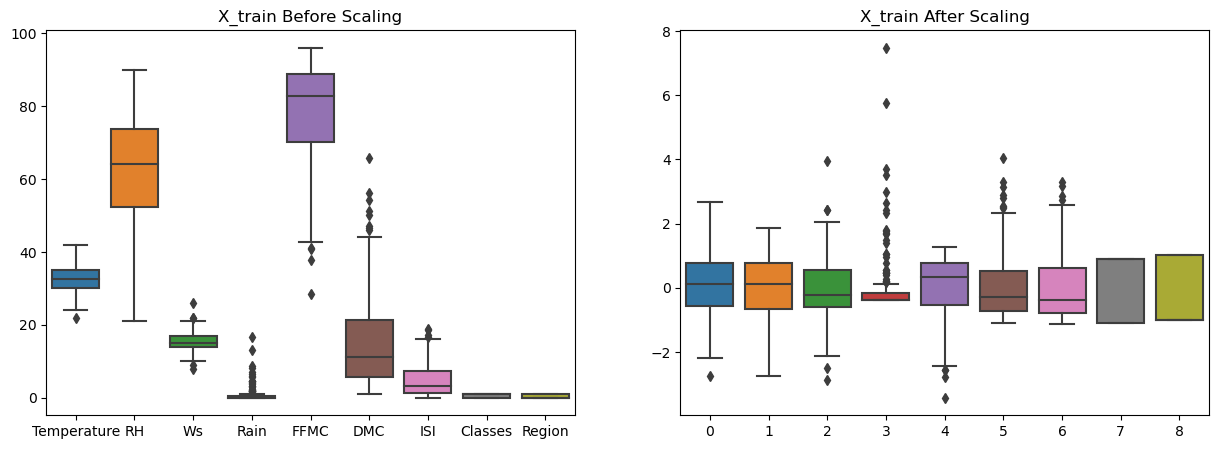

In [26]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression Model

Mean absolute error 0.5468236465249985
R2 Score 0.9847657384266951


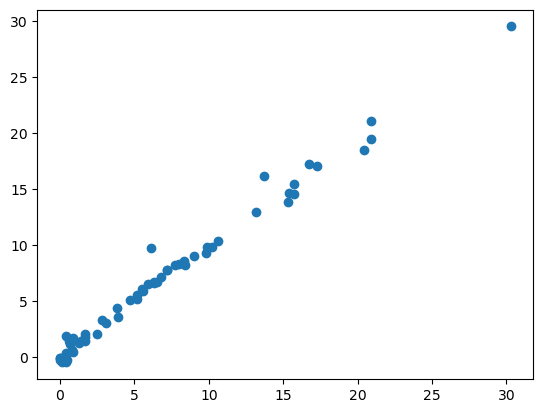

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Lasso Regression

Mean absolute error 1.133175994914409
R2 Score 0.9492020263112388


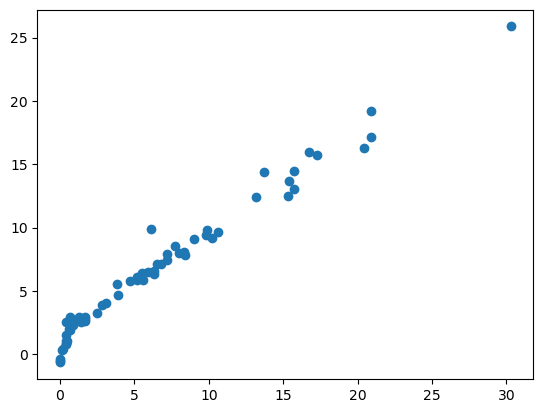

In [28]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Cross Validation Lasso

In [29]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

Mean absolute error 0.6199701158263433
R2 Score 0.9820946715928275


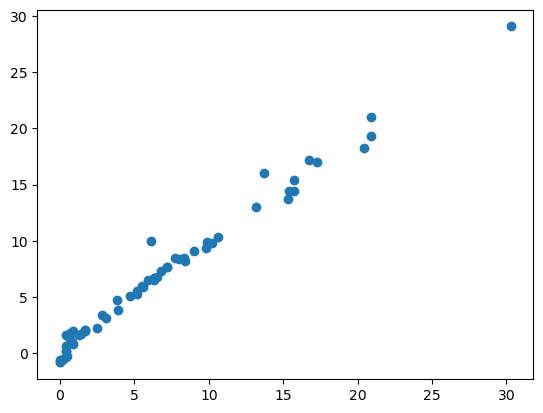

In [32]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression model

Mean absolute error 0.5642305340105692
R2 Score 0.9842993364555513


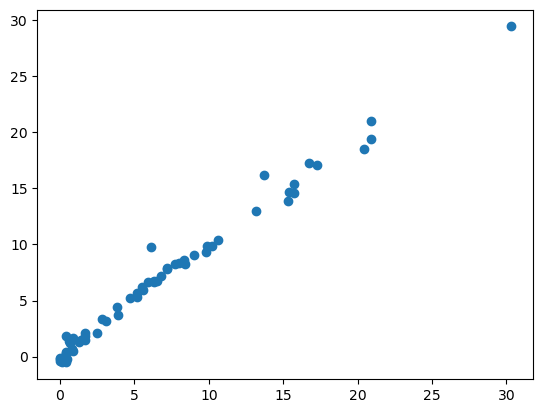

In [33]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.5642305340105692
R2 Score 0.9842993364555513


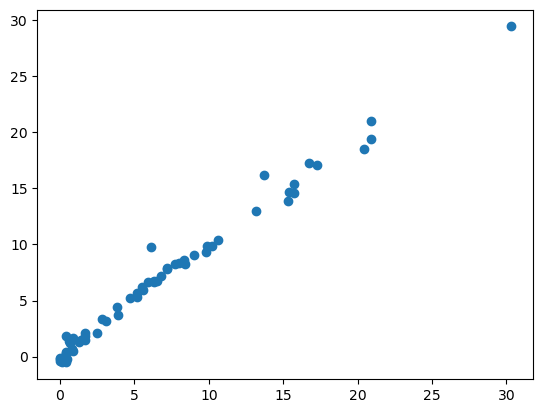

In [34]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [35]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_values': False}

## Elasticnet Regression

Mean absolute error 1.8822353634896005
R2 Score 0.8753460589519703


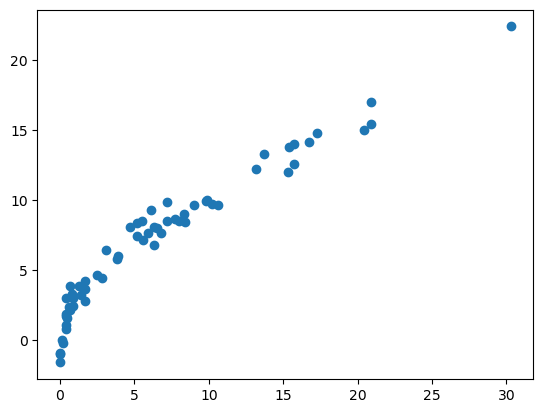

In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 0.6575946731430898
R2 Score 0.9814217587854941


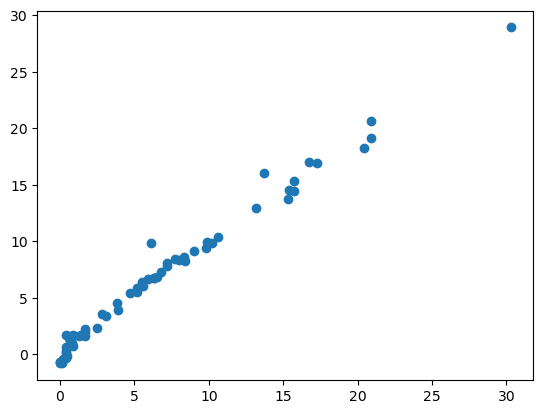

In [37]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

In [ ]:
elasticcv.alphas_